## Linear Regression

In [3]:
# Import Libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [4]:
# Load Dataset

df = pd.read_csv("Salary_Data.csv")

In [5]:
# Explore Dataset

df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [6]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [7]:
# Statistics 

df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [8]:
# Columns 
df.columns

Index(['YearsExperience', 'Salary'], dtype='str')

In [9]:
# Shape 
df.shape

(30, 2)

In [11]:
# Check Null Values

df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [12]:
# Split x and y

x = df[["YearsExperience"]]
y = df["Salary"]

In [14]:
# Train Test Split 

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
# Train model 
model = LinearRegression()

model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.532e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [16]:
# Prediction 
y_pred = model.predict(x_test)

In [17]:
# Evaluation 
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

6286.453830757749
49830096.85590839
0.9024461774180497


In [22]:
print(model.coef_)
print(model.intercept_)

[9423.81532303]
25321.583011776813


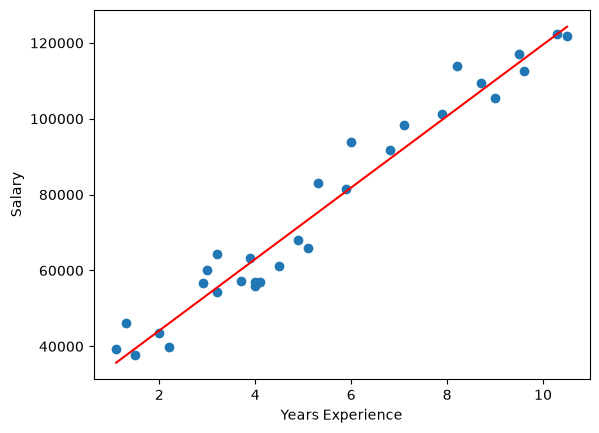

In [23]:
# Visualization 

plt.scatter(x,y)
plt.plot(x,model.predict(x), color = 'r')
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.show()

## Ridge Regression

In [28]:
from sklearn.linear_model import Ridge

df = pd.read_csv("Salary_Data.csv")

x = df[["YearsExperience"]]
y = df["Salary"]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model = Ridge(alpha=1.0)

model.fit(x_train,y_train)

y_pred = model.predict(x_test)

In [29]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

6274.687372409958
49974852.71999631
0.9021627846740267


In [30]:
print(model.coef_)
print(model.intercept_)

[9376.74948964]
25565.737022493304


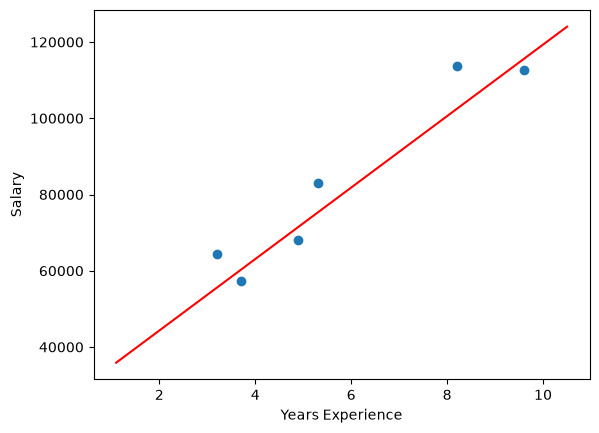

In [32]:
plt.scatter(x_test,y_test)
plt.plot(x,model.predict(x), color = 'r')
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.show()

## Lasso Regression

In [33]:
from sklearn.linear_model import Lasso

df = pd.read_csv("Salary_Data.csv")

x = df[["YearsExperience"]]
y = df["Salary"]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model = Lasso(alpha=1.0)

model.fit(x_train,y_train)

y_pred = model.predict(x_test)

In [34]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

6286.423714244487
49830434.55766544
0.9024455162895476


In [36]:
print(model.coef_)
print(model.intercept_)

[9423.69485698]
25322.207929426964


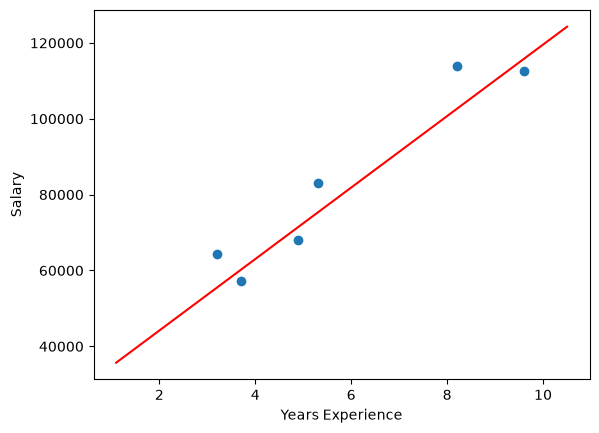

In [37]:
plt.scatter(x_test,y_test)
plt.plot(x,model.predict(x), color = 'r')
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.show()

## Elastic Net

In [38]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=1.0, l1_ratio=0.5)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

print(model.coef_)
print(model.intercept_)


6152.595250353593
52993668.24447989
0.8962527621642432
[8888.38100141]
28099.14855516301


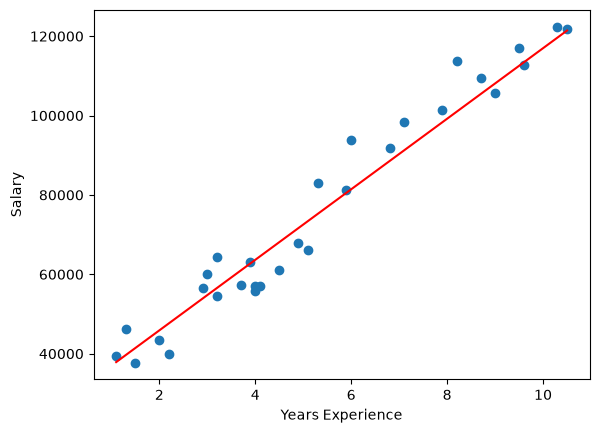

In [39]:
plt.scatter(x, y)
plt.plot(x, model.predict(x), color="red")
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.show()

## Decision Tree

In [40]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [41]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

8640.166666666666
101047709.83333333
0.8021759743735162


C:\Users\DELL\AppData\Local\Temp\ipykernel_16220\2823040379.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_grid = np.arange(min(x.values), max(x.values), 0.01)
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


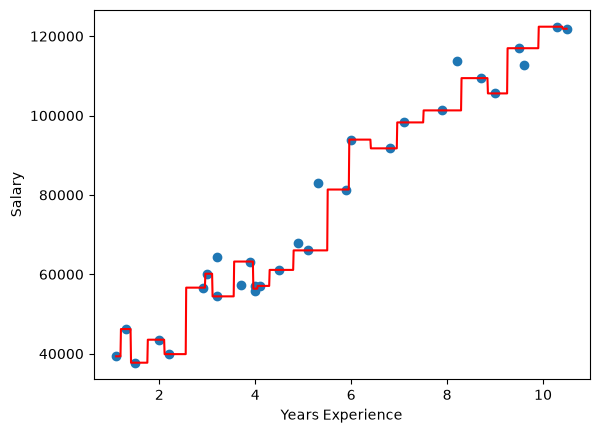

In [43]:
import numpy as np

x_grid = np.arange(min(x.values), max(x.values), 0.01)
x_grid = x_grid.reshape(-1, 1)

plt.scatter(x, y)
plt.plot(x_grid, model.predict(x_grid), color="red")
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.show()

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


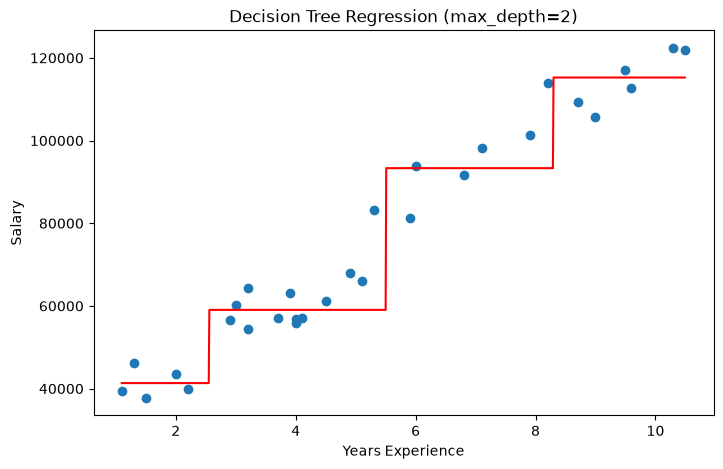

In [46]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import matplotlib.pyplot as plt

model = DecisionTreeRegressor(random_state=42, max_depth=2)

model.fit(x_train, y_train)

x_grid = np.arange(x.min().values[0], x.max().values[0], 0.01)
x_grid = x_grid.reshape(-1, 1)

plt.figure(figsize=(8,5))
plt.scatter(x, y)
plt.plot(x_grid, model.predict(x_grid), color="red")
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.title("Decision Tree Regression (max_depth=2)")
plt.show()

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


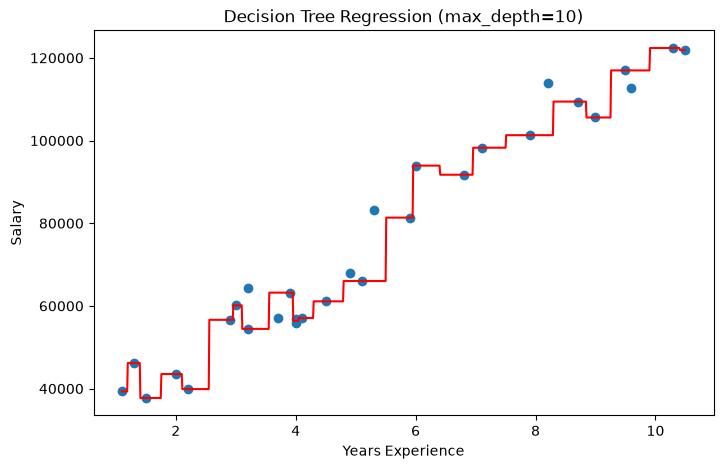

In [ ]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import matplotlib.pyplot as plt

model = DecisionTreeRegressor(random_state=42, max_depth=10)

model.fit(x_train, y_train)

x_grid = np.arange(x.min().values[0], x.max().values[0], 0.01)
x_grid = x_grid.reshape(-1, 1)

plt.figure(figsize=(8,5))
plt.scatter(x, y)
plt.plot(x_grid, model.predict(x_grid), color="red")
plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.title("Decision Tree Regression (max_depth=10)")
plt.show()